In [4]:
!pip install -q statsforecast
!pip install -q catboost
!pip install -q torch
!pip install -q torchinfo

In [5]:
import pickle
import pandas as pd
import numpy as np
import json
import math
import os
import sys
import importlib

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoTheta
import random

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary

import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:.2f}'.format

In [1]:
from google.colab import drive
drive.mount('/content/drive')

folder_path = "/content/drive/MyDrive/Colab_Notebooks/project_ts/data"

# Проверяем, что папка существует и переходим в неё
if os.path.exists(folder_path):
    os.chdir(folder_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
if "imp" not in sys.modules:
    sys.modules["imp"] = importlib

%load_ext autoreload
%autoreload 2

> ### **Цель работы**
> На небольшой выборке по одному продукту изучить характеристики датасета и понять, какие возможны архитектурные улучшения для более крупного размера данных.

План действий:
1. Получаем датасет.
2. Пытаемся оптимизировать датасет.
3. Делаем eda: пропуски, визуальный анализ временных рядов (строим графики), смотрим на тренды, сезонность, цикличность и на стационарность, ACF, PACF.
4. Делаем функцию для метрики.
5. STL-декомпозиция.
6. Naive, SeasonalNaive, auto.theta, auto.ets, auto.arima.
7. Определяемся с тем, как будем делать валидацию.
8. Прикручиваем catboost, lightgbm или xgboost - что больше понравится
9. Выбор DL модели
10. Реализация DL модели
11. Пишем выводы

> ### Подготовка данных
>
> Мы начали с небольшого куска данных. Решили взять продажи одного товара во всех магазинах. Взяли тот товар, по которому больше всего данных в датасете.
>
> Добавили информацию по ценам на нефть из таблицы oil.
>
> Из таблицы items узнали, что это товар не скоропортящийся, поэтому мы можем использовать просто метрику RMSLE.
>


In [6]:
dtypes = {
    'store_nbr': 'int8',
    'item_nbr': 'int32',
    'onpromotion': 'bool',
    'unit_sales': 'float32'
}

train = pd.read_csv("train_2017.csv",
                    dtype=dtypes,
                    parse_dates=['date'],
                    usecols=['date','store_nbr','item_nbr','onpromotion','unit_sales'],
                    low_memory=False)

train = train[train['date'] >= '2017-01-01'].copy()
print(f"Train shape после фильтра 2017: {train.shape}")

Train shape после фильтра 2017: (23808261, 5)


In [7]:
oil = pd.read_csv("oil.csv")
items = pd.read_csv("items.csv")

In [8]:
from modules.metrix import *
from modules.prepare_data import *
from modules.validation import expanding_window_validation
from modules.models import StatsforecastModel
from statsforecast.models import AutoETS, AutoTheta, Naive, SeasonalNaive
from modules.models import CatBoostRecursive
from modules.prepare_for_dl import *


In [13]:
data = transform_data(train, oil, items)

# EDA

> После обработки данных у нас остались только колонки с датой, номером магазина, таргетом, промо-акциями и ценами на нефть.
>
> Типы данных соответствуют тем, что мы указывали изначально.
>
> Всего у нас 54 магазина в выборке.
>
> Заметим, что цены на нефть не сильно волатильны: дисперсия составляет всего 3.12.
>
> Гораздо чаще акций на товары нет.

In [15]:
data.head(5)

,ds,store,y,onpromotion,dcoilwtico
0,2017-01-01,1,0.00,False,52.36
1,2017-01-02,1,9.00,False,52.36
2,2017-01-03,1,21.00,False,52.36
3,2017-01-04,1,30.00,False,53.26
4,2017-01-05,1,30.00,False,53.77


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12258 entries, 0 to 12257
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ds           12258 non-null  datetime64[ns]
 1   store        12258 non-null  int64         
 2   y            12258 non-null  float32       
 3   onpromotion  12258 non-null  bool          
 4   dcoilwtico   12258 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float32(1), float64(1), int64(1)
memory usage: 347.3 KB


In [17]:
display(data.describe())
display(data.describe(include = 'bool'))

,ds,store,y,dcoilwtico
count,12258,12258.00,12258.00,12258.00
mean,2017-04-24 00:00:00,27.50,37.77,49.47
min,2017-01-01 00:00:00,1.00,0.00,42.48
25%,2017-02-26 00:00:00,14.00,20.00,47.10
50%,2017-04-24 00:00:00,27.50,33.00,49.37
75%,2017-06-20 00:00:00,41.00,50.00,52.38
max,2017-08-15 00:00:00,54.00,210.00,54.48
std,NaN,15.59,24.48,3.12


,onpromotion
count,12258
unique,2
top,False
freq,10844


In [18]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

seed_everything()

> В рядах очевидна сезонность. Период мы посмотрим позже по графикам ACF и PACF.
>
> Можем заметить, что все данные имеют разный масштаб.
>
> У нас все ряды выровненные, потому что мы специально готовили данные так, чтобы ряды были одинаковыми по длине, а пропуски заполнены нулями. В условии говорилось: если нет каких-то дат, по продукт не покупался.
>
>

In [19]:
fig = go.Figure()

seed_everything()
random_ids = np.random.choice(data["store"].unique(), 10, replace=False)

for i in random_ids:
    fig.add_trace(
        go.Scatter(x=data[data["store"] == i]["ds"], y=data[data["store"] == i]["y"], name=str(i))
    )

fig.update_layout(
    title="10 случайных рядов из датасета",
    xaxis_title="Дата",
    yaxis_title="Значение ряда",
)

fig.show()

> На графиках мы можем заметить явную недельную сезонность, а также заметные лаги.
>
>
>


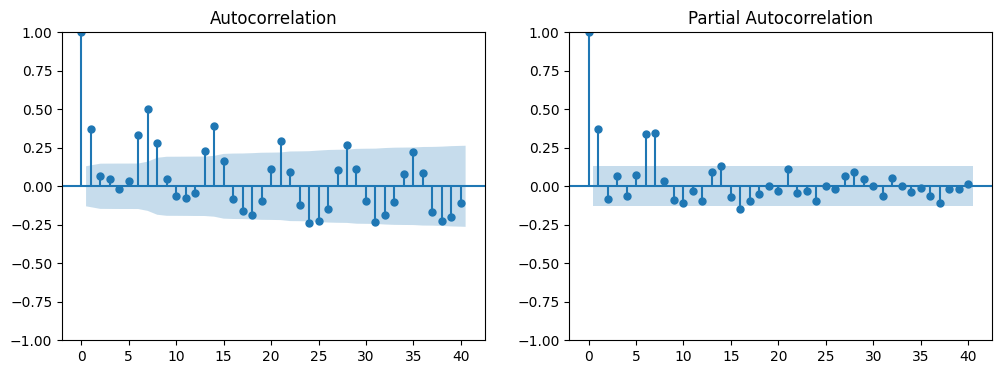

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(data['y'][data['store'] == 6], lags=40, ax=ax[0])
plot_pacf(data['y'][data['store'] == 6], lags=40, ax=ax[1])
plt.show()

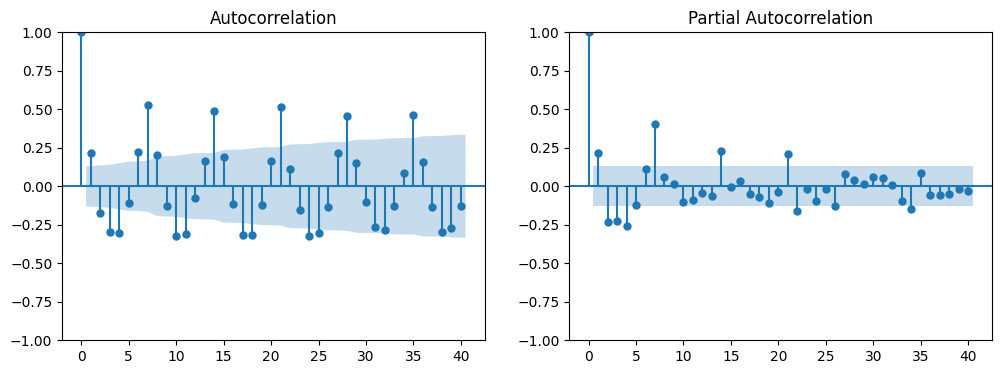

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(data['y'][data['store'] == 45], lags=40, ax=ax[0])
plot_pacf(data['y'][data['store'] == 45], lags=40, ax=ax[1])
plt.show()

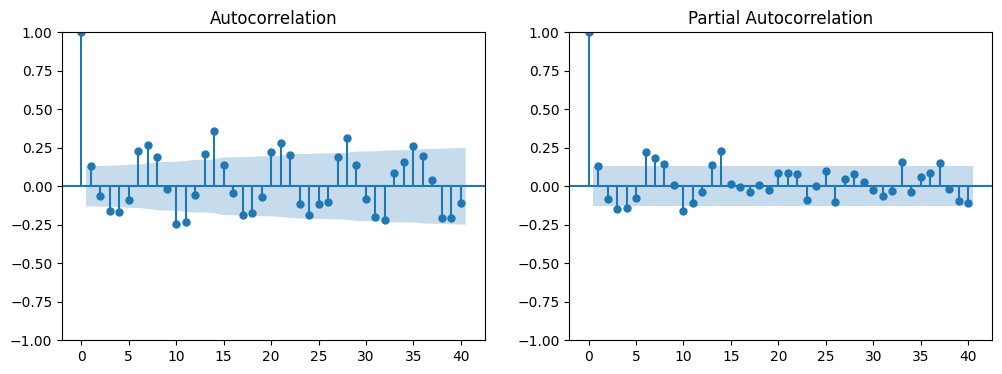

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(data['y'][data['store'] == 13], lags=40, ax=ax[0])
plot_pacf(data['y'][data['store'] == 13], lags=40, ax=ax[1])
plt.show()

> Графики STL разложения, в целом, подтверждают сделанные выводы. Однако, тренда не наблюдается, есть только значительные скачки.
>
>

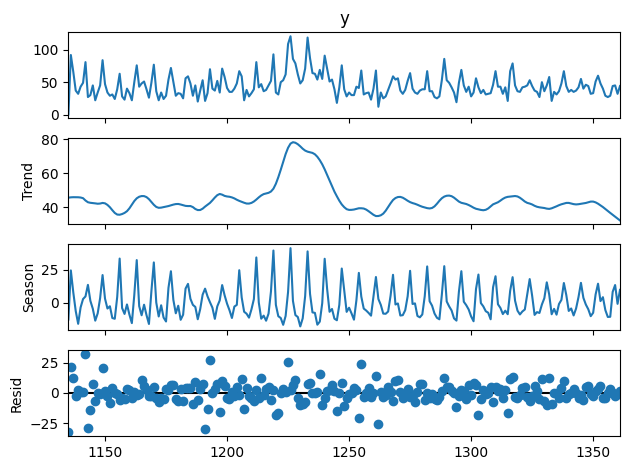

In [23]:
PERIOD = 7

stl = STL(data['y'][data['store'] == 6], period=PERIOD)
result = stl.fit()
result.plot()
plt.show()

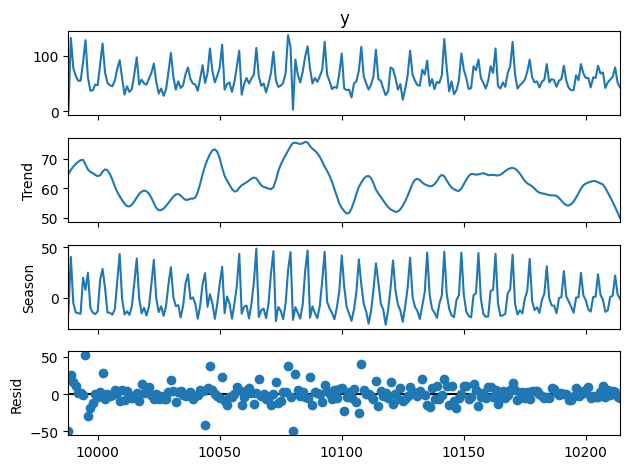

In [24]:
stl = STL(data['y'][data['store'] == 45], period=PERIOD)
result = stl.fit()
result.plot()
plt.show()

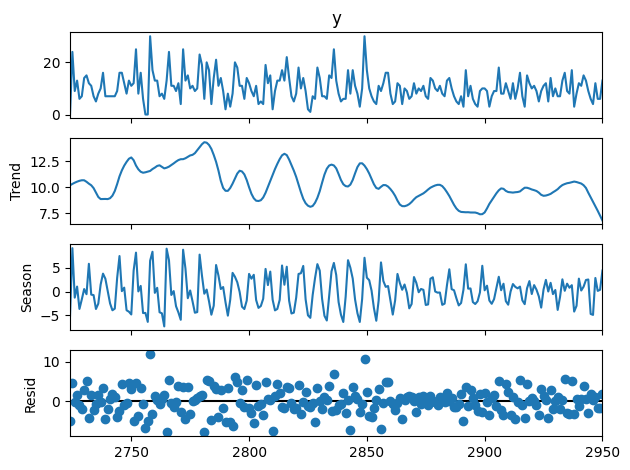

In [25]:
stl = STL(data['y'][data['store'] == 13], period=PERIOD)
result = stl.fit()
result.plot()
plt.show()

# Бейзлайн-модель

> Мы решили попробовать все предложенные модели.

In [26]:
min_date = data['ds'].min() + pd.Timedelta(days=14)
data = data[data['ds'] >= min_date].reset_index(drop=True)

In [27]:
HISTORY = 60
HORIZON = 16
START_TRAIN_SIZE = 180
STEP_SIZE = 7

SEASON_LENGTH = 7
FREQ = "D"

In [31]:
os.makedirs("saved_models", exist_ok=True)

all_results = {}

for model_obj, model_name in [
    (StatsforecastModel(Naive(), FREQ, HORIZON), "Naive"),
    (StatsforecastModel(SeasonalNaive(season_length=SEASON_LENGTH), FREQ, HORIZON), "SeasonalNaive"),
    (StatsforecastModel(AutoETS(season_length=SEASON_LENGTH), FREQ, HORIZON), "AutoETS"),
    (StatsforecastModel(AutoTheta(season_length=SEASON_LENGTH), FREQ, HORIZON), "AutoTheta"),
]:
    print(f"Evaluating model: {model_name}")
    results_df, trained_model = expanding_window_validation(
        data=data,
        model=model_obj,
        horizon=HORIZON,
        history=HISTORY,
        start_train_size=START_TRAIN_SIZE,
        step_size=STEP_SIZE,
        id_col="store",
        timestamp_col="ds",
        value_col="y",
    )

    all_results[model_name] = results_df

    file_path = f"saved_models/{model_name}_model.pkl"
    with open(file_path, "wb") as f:
        pickle.dump(trained_model, f)

Evaluating model: Naive
Evaluating model: SeasonalNaive
Evaluating model: AutoETS
Evaluating model: AutoTheta


In [33]:
all_results = (
    pd.concat(all_results.values(), keys=all_results.keys(), names=["model", "row_id"])
    .reset_index()
    .drop(columns=["row_id"])
)

metrics_df = (
    all_results
    .groupby(["model", "fold"], as_index=False)
    .apply(calculate_rmsle, include_groups=False)
    .reset_index(drop=True)
)

print("Среднее RMSLE по моделям:")
display(metrics_df.groupby("model").agg({"RMSLE": ["mean"]}))

Среднее и стандартное отклонение RMSLE по моделям:


,RMSLE
,mean
model,
AutoETS,0.38
AutoTheta,0.39
Naive,0.47
SeasonalNaive,0.46


> Экспоненциальное сглаживание лучше всего справилось с динамикой ряда. Разница с наивными прогнозами существенна.

# ML-модель

> Для анализа выбрали рекурсивный CatBoost с mimo стратегией прогнозирования. Данная модель была выбрана, потому что она учится быстрее. Мы решили, что, несмотря на то, что recursive mimo накапливает ошибку, для нашей задачи это не критично, поскольку спрос на товары является достаточно стабильным явлением.

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11502 entries, 0 to 11501
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ds           11502 non-null  datetime64[ns]
 1   store        11502 non-null  int64         
 2   y            11502 non-null  float32       
 3   onpromotion  11502 non-null  bool          
 4   dcoilwtico   11502 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float32(1), float64(1), int64(1)
memory usage: 325.9 KB


> Обратим внимание, что перед запуском модели логарифмируем целевую переменную. В катбусте нет реализации метрики RMSLE, и таким образом мы её реплицируем.

In [61]:
data['y'] = np.log1p(data['y'])

In [ ]:
recursive_mimo_results, trained_model_object = expanding_window_validation(
    data=data,
    model=CatBoostRecursive(model_horizon=16, history=HISTORY, horizon=HORIZON, freq=FREQ),
    horizon=HORIZON,
    history=HISTORY,
    start_train_size=START_TRAIN_SIZE,
    step_size=STEP_SIZE,
    id_col="store",
    timestamp_col="ds",
    value_col="y",
)

0:	learn: 2.6532741	test: 2.5585661	best: 2.5585661 (0)	total: 9.61s	remaining: 23m 52s
100:	learn: 1.2418203	test: 1.4504167	best: 1.4471094 (89)	total: 19m 29s	remaining: 9m 27s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 1.444940897
bestIteration = 113

Shrink model to first 114 iterations.
Шаг прогнозирования 1 из 1


In [ ]:
import pickle
with open("saved_models/full_model_with_weights.pkl", "wb") as f:
    pickle.dump(trained_model_object, f)

In [ ]:
ml_results_df = pd.concat(
    [
        recursive_mimo_results.assign(model="CatBoostRecursiveMIMO"),
    ],
    ignore_index=True,
)

ml_results_df['true_value'] =  np.expm1(ml_results_df['true_value'])
ml_results_df['predicted_value'] =  np.expm1(ml_results_df['predicted_value'])

metrics_df = (
    ml_results_df
    .groupby(["model", "fold"], as_index=False)
    .apply(calculate_rmsle, include_groups=False)
    .reset_index(drop=True)
)

display(metrics_df.groupby("model").agg({"RMSLE": ["mean"]}))

,RMSLE
,mean
model,
CatBoostRecursiveMIMO,0.38


> Результат катбуска оказался таким же как у AutoETS. Скорее всего, проблема в том, что у модели, во-первых, мало данных, а, во-вторых, не хватает дополнительных признаков.

# DL-модель

> Для дальнейшего анализа нами были выбраны две DL-модели: DLinear и TFT.
>
> DLinear выбрали как самую простую среди DL-моделей, чтобы было с чем сравливать дальше.
>
> TFT выбрали как хорошую индустриальную модель, в которой можно анализиловать дополнительные признаки.

In [40]:
seed_everything()
DEVICE = choose_device()

TARGET_COL = "y"
DATE_COL = "ds"
ID_COLS = ["store"]
KNOWN_FUTURE_COLS = ["onpromotion",]
PAST_COV_COLS = ['dcoilwtico',]

VAL_START = pd.Timestamp("2017-06-16")
TEST_START = pd.Timestamp("2017-07-16")
L = 60
H = 16
BATCH_SIZE = 256
NUM_WORKERS = 0

Using CPU


In [43]:
series_data = {}

for store_id, g in data.groupby("store", sort=False):
    g = g.sort_values("ds")

    dates = g["ds"].values
    y = g["y"].values.astype(np.float32)

    known = g[KNOWN_FUTURE_COLS].astype(np.float32).values
    past_cov = g[PAST_COV_COLS].astype(np.float32).values

    train_mask = (g["ds"] < VAL_START).values
    y_tr = y[train_mask]

    mu = float(y_tr.mean()) if len(y_tr) else 0.0
    sd = float(y_tr.std()) if len(y_tr) else 1.0
    sd = max(sd, 1e-4)

    y_n = (y - mu) / sd

    series_data[store_id] = dict(
        dates=dates,
        y=y_n,
        y_mu=mu,
        y_sd=sd,
        known=known,
        past_cov=past_cov,
        store_id=store_id,
    )

In [44]:
class WindowDataset(Dataset):
    def __init__(self, series_data, keys, t_indices_by_key, L, H):
        self.items = []
        self.series_data = series_data
        self.L = L
        self.H = H
        for k in keys:
            for t in t_indices_by_key[k]:
                self.items.append((k, t))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        (k, t) = self.items[i]
        d = self.series_data[k]
        y = d["y"]
        known = d["known"]
        past_cov = d["past_cov"]

        x_y = y[t - self.L + 1 : t + 1]  # (L, )
        x_past_cov = past_cov[t - self.L + 1 : t + 1, :]  # (L, Cp)
        x_known_past = known[t - self.L + 1 : t + 1, :]  # (L, Cf)
        x_known_fut = known[t + 1 : t + self.H + 1, :]  # (H, Cf)

        y_fut = y[t + 1 : t + self.H + 1]  # (H, )

        return {
            "x_y": torch.tensor(x_y).float(),  # (L, )
            "x_past_cov": torch.tensor(x_past_cov).float(),  # (L, Cp)
            "x_known_past": torch.tensor(x_known_past).float(),  # (L, Cf)
            "x_known_fut": torch.tensor(x_known_fut).float(),  # (H, Cf)
            "y": torch.tensor(y_fut).float(),  # (H, )
            "store_id": torch.tensor(d["store_id"]).long(),
        }


keys = list(series_data.keys())
tidx_train, tidx_val, tidx_test = {}, {}, {}

for k in keys:
    d = series_data[k]
    tr, va, te = build_window_index(d["dates"], L, H, VAL_START, TEST_START)
    tidx_train[k], tidx_val[k], tidx_test[k] = tr, va, te

train_ds = WindowDataset(series_data, keys, tidx_train, L, H)
val_ds = WindowDataset(series_data, keys, tidx_val, L, H)
test_ds = WindowDataset(series_data, keys, tidx_test, L, H)

In [45]:
train_dl = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
val_dl = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
test_dl = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

In [46]:
class MovingAvg(nn.Module):
    def __init__(self, k=25):
        super().__init__()
        self.k = k
        self.pool = nn.AvgPool1d(kernel_size=k, stride=1, padding=k // 2, count_include_pad=False)

    def forward(self, x):  # x: (B, L, 1)
        x = x.transpose(1, 2)  # (B ,1, L)
        ma = self.pool(x)  # (B, 1, L)
        ma = ma.transpose(1, 2)  # (B, L, 1)
        return ma


class DLinear(nn.Module):
    def __init__(self, L, H, ma_k=25):
        super().__init__()
        self.ma = MovingAvg(ma_k)
        self.lin_tr = nn.Linear(L, H)
        self.lin_se = nn.Linear(L, H)

    def forward(self, batch):
        x = batch["x_y"].unsqueeze(-1)  # (B, L, 1)
        trend = self.ma(x)  # (B, L, 1)
        seasonal = x - trend  # (B, L, 1)
        tr = self.lin_tr(trend.squeeze(-1))  # (B, H)
        se = self.lin_se(seasonal.squeeze(-1))  # (B, H)
        return tr + se

In [47]:
m_dlin = DLinear(L, H, ma_k=25)
print(m_dlin)
summary(
    m_dlin,
    input_data={
        "batch": {
            "x_y": torch.zeros(2, L),
            "y": torch.zeros(2, H),
            "x_past_cov": torch.zeros(2, L, len(PAST_COV_COLS)),
            "x_known_past": torch.zeros(2, L, len(KNOWN_FUTURE_COLS)),
            "x_known_fut": torch.zeros(2, H, len(KNOWN_FUTURE_COLS)),
            "store_id": torch.zeros(2, dtype=torch.long),
        }
    },
)

m_dlin = train_loop(m_dlin, train_dl, val_dl, epochs=10, lr=1e-3)
test_loss, test_sm, preds = validation_loop(m_dlin, test_dl, return_preds=True)
print("DLinear | test loss:", test_loss, "test rmse:", test_sm)

y_true = preds["y_true"]
y_pred = preds["y_pred"]
print("DLinear | test rmse:", rmse_numpy(y_true, y_pred))


DLinear(
  (ma): MovingAvg(
    (pool): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(12,))
  )
  (lin_tr): Linear(in_features=60, out_features=16, bias=True)
  (lin_se): Linear(in_features=60, out_features=16, bias=True)
)
Epoch 01 | train loss 1.0114 rmse 1.0114 | val loss 1.0506 rmse 1.0506
Epoch 02 | train loss 0.9425 rmse 0.9425 | val loss 0.9707 rmse 0.9707
Epoch 03 | train loss 0.9102 rmse 0.9102 | val loss 0.9373 rmse 0.9373
Epoch 04 | train loss 0.8892 rmse 0.8892 | val loss 0.9151 rmse 0.9151
Epoch 05 | train loss 0.8721 rmse 0.8721 | val loss 0.9003 rmse 0.9003
Epoch 06 | train loss 0.8612 rmse 0.8612 | val loss 0.8880 rmse 0.8880
Epoch 07 | train loss 0.8478 rmse 0.8478 | val loss 0.8761 rmse 0.8761
Epoch 08 | train loss 0.8420 rmse 0.8420 | val loss 0.8677 rmse 0.8677
Epoch 09 | train loss 0.8414 rmse 0.8414 | val loss 0.8642 rmse 0.8642
Epoch 10 | train loss 0.8305 rmse 0.8305 | val loss 0.8621 rmse 0.8621
DLinear | test loss: 0.9787882566452026 test rmse: 0.97878825

In [57]:
os.makedirs("saved_models", exist_ok=True)

MODEL_PATH_DLIN = "saved_models/dlinear_model.pth"

checkpoint_dlin = {
    'model_state_dict': m_dlin.state_dict(),
    'config': {
        'L': L,
        'H': H,
        'ma_k': 25
    },

    'metrics': {
        'test_loss': test_loss,
        'test_rmse': test_sm
    },
    'columns': {
        'past_cov': PAST_COV_COLS,
        'known_future': KNOWN_FUTURE_COLS
    }
}

torch.save(checkpoint_dlin, MODEL_PATH_DLIN)



In [62]:
data['store'], _ = pd.factorize(data['store'])
num_unique_stores = data['store'].nunique()
print(f"Подготовлено магазинов: {num_unique_stores}")

class MiniTFT(nn.Module):
    def __init__(self, L, H, n_stores, d_static=16, d_model=64, nhead=4):
        super().__init__()
        self.emb_store = nn.Embedding(n_stores, d_static)
        self.static_proj = nn.Linear(d_static, d_model)
        self.enc_in = nn.Linear(1 + len(PAST_COV_COLS) + len(KNOWN_FUTURE_COLS), d_model)
        self.dec_in = nn.Linear(len(KNOWN_FUTURE_COLS), d_model)
        self.enc_lstm = nn.LSTM(d_model, d_model, batch_first=True)
        self.dec_lstm = nn.LSTM(d_model, d_model, batch_first=True)
        self.attn = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        self.head = nn.Linear(d_model, 3)

    def forward(self, batch):
        static = self.static_proj(self.emb_store(batch["store_id"])) # (B, d_model)
        enc_x = torch.cat([batch["x_y"].unsqueeze(-1), batch["x_past_cov"], batch["x_known_past"]], dim=-1)
        enc_out, (h, c) = self.enc_lstm(self.enc_in(enc_x) + static.unsqueeze(1))
        dec_x = self.dec_in(batch["x_known_fut"]) + static.unsqueeze(1)
        dec_out, _ = self.dec_lstm(dec_x, (h, c))
        attn_out, _ = self.attn(dec_out, enc_out, enc_out)
        return self.head(attn_out)

m_tft = MiniTFT(L, H, n_stores=num_unique_stores)
m_tft = train_loop_tft(m_tft, train_dl, val_dl, epochs=10)
test_loss, test_rmse, preds = validation_loop(m_tft, test_dl, return_preds=True, quantile_idx=1)
print(f"MiniTFT Test RMSLE: {test_rmse:.4f}")


Подготовлено магазинов: 54
Epoch 01 | Val RMSE: 1.0766
Epoch 02 | Val RMSE: 1.0747
Epoch 03 | Val RMSE: 1.0757
Epoch 04 | Val RMSE: 1.0721
Epoch 05 | Val RMSE: 1.0717
Epoch 06 | Val RMSE: 1.0720
Epoch 07 | Val RMSE: 1.0728
Epoch 08 | Val RMSE: 1.0720
Epoch 09 | Val RMSE: 1.0742
Epoch 10 | Val RMSE: 1.0644
MiniTFT Test RMSLE: 1.0210


In [51]:
MODEL_PATH = "saved_models/mini_tft_model.pth"

checkpoint = {
    'model_state_dict': m_tft.state_dict(),
    'config': {
        'L': L,
        'H': H,
        'n_stores': num_unique_stores,
        'd_static': 16,
        'd_model': 64,
        'nhead': 4
    },
    'store_mapping': list(series_data.keys())
}

with open(MODEL_PATH, "wb") as f:
    torch.save(checkpoint, f)

> DL-модели показали себя не очень хорошо. Предположительно, это связано с маленьким количеством данных. Также можно было бы предположить, что бейзлайн прогноз просто очень хорошо работает на этих данных, но мы знаем, что в топовых решениях соревнования были более сложные, чем бейзлайн, модели.
>
>


> ### **Выводы по моделям**
>|Модель|RMSLE|
>|-|-|
>|TFT|1.02|
>|DLinear|0.98|
>|Naive|0.47|
>|SeasonalNaive|0.46|
>|AutoTheta|0.39|
>|AutoETS|0.38|
>|CatBoostRecursiveMIMO|0.38|
>
> Лучше всего себя показали в рамках данного эксперимента CatBoostRecursiveMIMO и AutoETS.